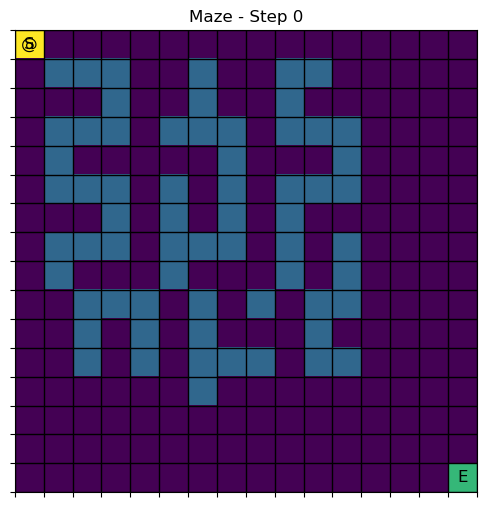

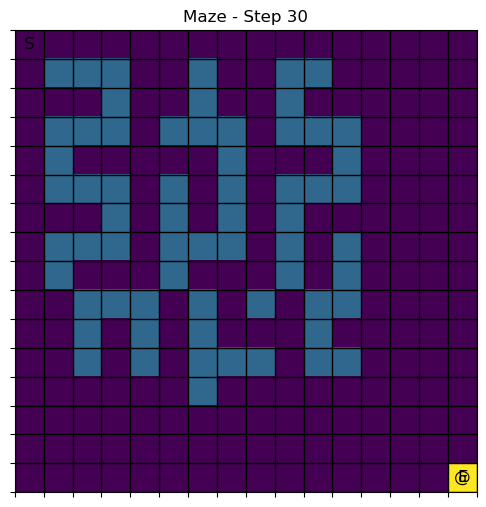

In [13]:
## maze_env.py

from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt


class MazeEnv:
    def __init__(self):
        # Grid size
        self.GRID_ROWS = 16
        self.GRID_COLS = 16

        # Walls copied from your maze layout
        self.walls = {
            (1, 1), (1, 2), (1, 3),
            (2, 3),
            (3, 1), (3, 2), (3, 3),

            (1, 6), (2, 6), (3, 6),
            (3, 5), (3, 7),
            (4, 7),

            (1, 9), (1, 10),
            (2, 9),
            (3, 9), (3, 10), (3, 11),
            (4, 11),

            (5, 1), (5, 2), (5, 3),
            (6, 3),
            (7, 1), (7, 2), (7, 3),
            (8, 1),

            (5, 5), (6, 5), (7, 5),
            (7, 6), (7, 7),
            (5, 7),

            (5, 9), (6, 9), (7, 9),
            (5, 10), (5, 11),
            (7, 11), (8, 11),

            (9, 2), (10, 2), (11, 2),
            (9, 3), (9, 4),
            (11, 4),

            (9, 6), (10, 6), (11, 6),
            (11, 7), (11, 8),
            (9, 8),

            (9, 10), (10, 10), (11, 10),
            (9, 11),
            (11, 11),

            (4, 1),
            (6, 7),
            (8, 5),
            (8, 9),
            (10, 4),
            (12, 6),
        }

        # Start and exit positions
        self.start_pos = (0, 0)
        self.exit_pos = (self.GRID_ROWS - 1, self.GRID_COLS - 1)

        # Player position (initialized to start)
        self.player_row, self.player_col = self.start_pos

        # Episode control
        self.max_steps = 500
        self.steps_taken = 0

        # ---------------------------------------------------------
        # GYM SPACES
        # ---------------------------------------------------------

        # Action space: 4 discrete moves
        self.action_space = spaces.Discrete(4)

        # Observation space: (row, col) normalized to [0, 1]
        # Example: (0.0, 0.0) at start, (1.0, 1.0) at bottom-right
        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0], dtype=np.float32),
            high=np.array([1.0, 1.0], dtype=np.float32),
            dtype=np.float32
        )

    # ---------------------------------------------------------
    # RESET
    # ---------------------------------------------------------
    def reset(self, seed=None, options=None):
        self.player_row, self.player_col = self.start_pos
        self.steps_taken = 0
        obs = self._get_obs()
        return obs, {}

    # ---------------------------------------------------------
    # OBSERVATION
    # ---------------------------------------------------------
    def _get_obs(self):
        # Normalize coordinates to [0, 1]
        return np.array([
            self.player_row / (self.GRID_ROWS - 1),
            self.player_col / (self.GRID_COLS - 1)
        ], dtype=np.float32)

    # ---------------------------------------------------------
    # STEP
    # ---------------------------------------------------------
    def step(self, action):
        self.steps_taken += 1

        new_row, new_col = self.player_row, self.player_col

        if action == 0:      # up
            new_row -= 1
        elif action == 1:    # down
            new_row += 1
        elif action == 2:    # left
            new_col -= 1
        elif action == 3:    # right
            new_col += 1

        # Check boundaries and walls
        if (0 <= new_row < self.GRID_ROWS and
            0 <= new_col < self.GRID_COLS and
            (new_row, new_col) not in self.walls):
            self.player_row, self.player_col = new_row, new_col

        # Reward shaping
        reward = -0.1
        terminated = False

        if (self.player_row, self.player_col) == self.exit_pos:
            reward = 10.0
            terminated = True

        if self.steps_taken >= self.max_steps:
            terminated = True

        obs = self._get_obs()
        info = {}

        return obs, reward, terminated, False, info

    # ---------------------------------------------------------
    # OPTIONAL DEBUG RENDER
    # ---------------------------------------------------------
    #def render(self):
    #    print(f"Player at: ({self.player_row}, {self.player_col})")

    # ---------------------------------------------------------
    # VISUAL RENDER
    # ---------------------------------------------------------
    def render(self):
        # Create empty grid
        grid = np.zeros((self.GRID_ROWS, self.GRID_COLS))

        # Mark walls
        for wall_row, wall_col in self.walls:
            grid[wall_row, wall_col] = 1

        # Mark exit
        exit_row, exit_col = self.exit_pos
        grid[exit_row, exit_col] = 2

        # Mark player
        grid[self.player_row, self.player_col] = 3

        # Draw maze
        plt.figure(figsize=(6, 6))
        plt.imshow(grid)

        # Add grid lines
        plt.xticks(np.arange(-0.5, self.GRID_COLS, 1), [])
        plt.yticks(np.arange(-0.5, self.GRID_ROWS, 1), [])
        plt.grid(color="black", linewidth=1)

        # Add labels
        plt.text(
            self.start_pos[1],
            self.start_pos[0],
            "S",
            ha="center",
            va="center",
            fontsize=12
        )

        plt.text(
            exit_col,
            exit_row,
            "E",
            ha="center",
            va="center",
            fontsize=12
        )

        plt.text(
            self.player_col,
            self.player_row,
            "@",
            ha="center",
            va="center",
            fontsize=12
        )

        plt.title(f"Maze - Step {self.steps_taken}")
        plt.show()



env = MazeEnv()
obs, info = env.reset()
env.render()
'''
0 = up
1 = down
2 = left
3 = right
'''
env.step(3)   # right
env.step(3)   # right again
env.step(3)  
env.step(3) 
env.step(3) 
env.step(3) 
env.step(3) 
env.step(3) 
env.step(3) 
env.step(3) 
env.step(3) 
env.step(3) 
env.step(3) 
env.step(3) 
env.step(3) 
env.step(1) 
env.step(1) 
env.step(1)
env.step(1) 
env.step(1) 
env.step(1) 
env.step(1) 
env.step(1) 
env.step(1) 
env.step(1) 
env.step(1) 
env.step(1) 
env.step(1) 
env.step(1) 
env.step(1)
env.render()
